# **Python Data Processing and Analytics**

This notebook focuses on Python-based data processing, analysis, and visualisation for the NorthStar Urban Mobility and Logistics case study. Python was used to clean, process, analyse, and visualise operational datasets in order to identify patterns affecting delivery performance, customer complaints, operational efficiency, and service reliability.

The analysis was performed using libraries including Pandas, NumPy, Matplotlib, and Seaborn to support data manipulation, statistical analysis, and visual reporting. The notebook investigates operational trends across deliveries, hubs, drivers, vehicles, complaints, and customer activity to identify the key factors contributing to delays, failed deliveries, increased operational costs, and customer dissatisfaction.

The objective of this section is to demonstrate how Python analytics techniques can support data-driven decision-making through effective data processing, analytical insights, and visual interpretation of business performance.

In [1]:
# install packages
!pip install pandas numpy matplotlib seaborn scipy scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import json
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [2]:
# Load Datasets
BASE = 'https://raw.githubusercontent.com/Neha-Savahir/northstar-analysis/refs/heads/main/northstar_dataset/'

deliveries = pd.read_csv(BASE + 'deliveries.csv')
orders     = pd.read_csv(BASE + 'orders.csv')
drivers    = pd.read_csv(BASE + 'drivers.csv')
vehicles   = pd.read_csv(BASE + 'vehicles.csv')
hubs       = pd.read_csv(BASE + 'hubs.csv')
complaints = pd.read_csv(BASE + 'complaints.csv')
incidents  = pd.read_csv(BASE + 'incidents.csv')
customers  = pd.read_csv(BASE + 'customers.csv')
app_events = pd.read_csv(BASE + 'app_events.csv')

datasets = {
    'deliveries': deliveries,
    'orders': orders,
    'drivers': drivers,
    'vehicles': vehicles,
    'hubs': hubs,
    'complaints': complaints,
    'incidents': incidents,
    'customers': customers,
    'app_events': app_events
}

for name, df in datasets.items():
    print(f"{name:<15} {df.shape}")

deliveries      (950, 13)
orders          (1250, 11)
drivers         (170, 8)
vehicles        (120, 8)
hubs            (8, 5)
complaints      (320, 10)
incidents       (280, 7)
customers       (650, 9)
app_events      (640, 10)


# **Data Cleaning & Standardisation**

## **Zone Normalisation**

In [3]:
# Mapping inconsistent zone labels into standard format
ZONE_MAP = {
    'ctr': 'Central', 'central': 'Central',
    'north': 'North', 'south': 'South',
    'east': 'East', 'west': 'West',
    'airport': 'Airport', 'riverside': 'Riverside'
}

# Function to clean and standardise zone values
def normalise_zone(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    return ZONE_MAP.get(val, val.title())

# Columns containing zone information across datasets
zone_cols = {
    'orders': ['pickup_zone', 'dropoff_zone'],
    'drivers': ['base_zone'],
    'vehicles': ['assigned_zone'],
    'customers': ['home_zone']
}

# Dataset references for iteration
df_refs = {
    'orders': orders,
    'drivers': drivers,
    'vehicles': vehicles,
    'customers': customers
}

# Apply standardisation across all relevant datasets
for df_name, cols in zone_cols.items():
    for col in cols:
        df_refs[df_name][col] = df_refs[df_name][col].apply(normalise_zone)

In [4]:
# Check value distribution after standardisation
print(orders['pickup_zone'].value_counts().head())
print(drivers['base_zone'].value_counts().head())
print(customers['home_zone'].value_counts().head())

pickup_zone
Central    238
East       207
South      181
North      174
West       155
Name: count, dtype: int64
base_zone
North      36
South      29
Central    28
East       21
West       20
Name: count, dtype: int64
home_zone
North        111
Central      110
South         92
Riverside     91
East          89
Name: count, dtype: int64


**Interpretation**

The data shows that Central zone has the highest activity in pickup locations (238 records), indicating it is the most active operational area. East and South zones also show strong activity levels, while West has the lowest. Driver base locations are mainly concentrated in North and South zones, suggesting uneven driver distribution across regions. Customer home zones are relatively balanced, though Central and North remain slightly dominant. Overall, the dataset shows clear regional variation in demand and operations across zones.

## **Missing Value Handling**

In [5]:
# Convert battery health to numeric and handle missing values using vehicle type median
vehicles['battery_health_pct'] = pd.to_numeric(vehicles['battery_health_pct'], errors='coerce')
vehicles['battery_health_pct'] = vehicles.groupby('vehicle_type')['battery_health_pct'] \
    .transform(lambda x: x.fillna(x.median()))

# Fill missing compensation values with 0
complaints['compensation_amount'] = pd.to_numeric(
    complaints['compensation_amount'], errors='coerce'
).fillna(0)

# Convert ratings to numeric and fill missing values using hub-wise median
deliveries['customer_rating_post_delivery'] = pd.to_numeric(
    deliveries['customer_rating_post_delivery'], errors='coerce'
)

deliveries['customer_rating_post_delivery'] = deliveries.groupby('hub_id')[
    'customer_rating_post_delivery'
].transform(lambda x: x.fillna(x.median()))

In [6]:
# Check Missing Values After Cleaning
print(vehicles['battery_health_pct'].isnull().sum())
print(complaints['compensation_amount'].isnull().sum())
print(deliveries['customer_rating_post_delivery'].isnull().sum())

0
0
0


**Interpretation**

All missing values in key operational variables have been successfully handled, as confirmed by zero remaining null values. Battery health values were imputed using vehicle-type medians to preserve realistic performance trends, while missing customer ratings were filled using hub-level medians to maintain local consistency. Compensation amounts were standardised by replacing missing values with zero, ensuring complete financial records. Overall, the dataset is now fully complete and suitable for reliable operational analysis.

## **Categorical Standardisation**

In [7]:
# Standardise delivery status values for consistent analysis
deliveries['delivery_status'] = deliveries['delivery_status'].str.strip().str.lower()

**Interpretation**

Standardising delivery status ensures consistent categorisation of delivery outcomes, enabling accurate feature creation and analysis.

## **Date Parsing & Type Conversion**

In [8]:
# Function to safely convert columns into datetime format
def parse_dt(series):
    return pd.to_datetime(series, errors='coerce', dayfirst=True)

# Columns containing date/time information across datasets
datetime_cols = {
    'deliveries': 'dispatch_time',
    'orders': 'order_created_at',
    'complaints': 'created_at',
    'incidents': 'reported_at',
    'app_events': 'event_timestamp'
}

# Apply datetime conversion across all relevant datasets
for df_name, col in datetime_cols.items():
    datasets[df_name][col] = parse_dt(datasets[df_name][col])

In [9]:
#Check Data Types
print(deliveries['dispatch_time'].dtype)
print(orders['order_created_at'].dtype)
print(complaints['created_at'].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]


**Interpretation**

All date and time fields have been successfully converted into datetime64 format, confirming that temporal data is now correctly structured. This enables accurate time-series analysis, including trend detection, peak activity identification, and operational timing comparisons across datasets. The successful conversion ensures consistency in time-based calculations across all systems



## **Duplicate & Data Quality Check**

In [10]:
# Check for duplicate records across all datasets
for name, df in datasets.items():
    print(name, df.duplicated().sum())


deliveries 0
orders 0
drivers 0
vehicles 0
hubs 0
complaints 0
incidents 0
customers 0
app_events 0


**Numeric Data Profiling**




In [11]:
# Summary statistics for key operational variables
numeric_cols = ['route_distance_km', 'fuel_or_charge_cost', 'order_value']

for col in numeric_cols:
    if col in deliveries.columns:
        print(col)
        print(deliveries[col].describe())

route_distance_km
count    950.000000
mean      13.909316
std        7.477907
min        1.200000
25%        9.135000
50%       12.840000
75%       16.835000
max       41.940000
Name: route_distance_km, dtype: float64
fuel_or_charge_cost
count    950.000000
mean      12.841295
std        4.336468
min        2.500000
25%        9.925000
50%       12.645000
75%       15.697500
max       29.430000
Name: fuel_or_charge_cost, dtype: float64


In [12]:
# Check dataset size after cleaning
print(deliveries.shape)
print(orders.shape)

(950, 13)
(1250, 11)


**Interpretation**

No duplicate records were found across any dataset, confirming strong data integrity. Numerical summaries indicate realistic operational distributions, with moderate variation in delivery distance and cost, including a few high-value outliers. Dataset shape verification confirms that data structure remains intact after cleaning, ensuring no unintended data loss. Overall, the dataset is clean, consistent, and reliable for further analysis.

# **Feature Engineering**

## **Delivery Performance Features**

Objective:

To transform raw delivery data into meaningful performance indicators that help identify failures, delays, and operational inefficiencies.

In [13]:
# Binary flags for delivery outcomes
deliveries['is_failed'] = (deliveries['delivery_status'] == 'failed').astype(int)
deliveries['is_delayed'] = (deliveries['delivery_status'] == 'delayed').astype(int)

# Combined flag for any delivery issue (failed or delayed)
deliveries['is_problem'] = deliveries['is_failed'] | deliveries['is_delayed']

# Calculate cost efficiency per kilometre
deliveries['cost_per_km'] = (
    deliveries['fuel_or_charge_cost'] /
    deliveries['route_distance_km'].replace(0, np.nan)
)

In [14]:
# Verify newly created feature engineering columns and check their distributions for correctness
print(deliveries[['is_failed','is_delayed','is_problem','cost_per_km']].head())
print(deliveries['cost_per_km'].describe())
print(deliveries['is_failed'].value_counts())

   is_failed  is_delayed  is_problem  cost_per_km
0          1           0           1     0.698146
1          0           0           0     1.296905
2          0           0           0     1.074495
3          0           1           1     0.829476
4          0           0           0     0.634986
count    950.000000
mean       1.261662
std        1.239145
min        0.173974
25%        0.702991
50%        0.950332
75%        1.329252
max       12.363636
Name: cost_per_km, dtype: float64
is_failed
0    818
1    132
Name: count, dtype: int64


**Interpretation**

This feature engineering step transforms raw delivery data into meaningful operational indicators. Binary flags for failed and delayed deliveries help identify service issues clearly, while the combined problem flag captures overall delivery inefficiency. The cost per kilometre metric standardises operational cost against distance, enabling better comparison of delivery efficiency across routes.

## **Driver Risk Score**

Objective:
To evaluate driver performance by combining delivery failures, delays, and route override behaviour into a single risk metric.

In [34]:
# Create driver-level aggregated metrics
driver_stats = deliveries.groupby('driver_id').agg({
    'is_failed': 'mean',
    'is_delayed': 'mean',
    'manual_route_override_count': 'mean'
}).reset_index()

# Remove existing columns to avoid duplicate merge conflicts
drivers = drivers.drop(
    columns=['is_failed', 'is_delayed', 'manual_route_override_count'],
    errors='ignore'
)

# Merge aggregated metrics into drivers dataset
drivers = drivers.merge(
    driver_stats,
    on='driver_id',
    how='left'
)

# Normalize route override count
drivers['manual_route_override_count_norm'] = (
    drivers['manual_route_override_count'] /
    drivers['manual_route_override_count'].max()
)

# Compute driver risk score
drivers['risk_score'] = (
    drivers['is_failed'].fillna(0) * 0.4 +
    drivers['is_delayed'].fillna(0) * 0.3 +
    drivers['manual_route_override_count_norm'].fillna(0) * 0.3
)

# Display results
print(drivers[['driver_id', 'risk_score']].head())
print(drivers['risk_score'].describe())

  driver_id  risk_score
0      D001    0.161111
1      D002    0.209524
2      D003    0.191667
3      D004    0.218519
4      D005    0.300000
count    170.000000
mean       0.184329
std        0.104346
min        0.000000
25%        0.109921
50%        0.183333
75%        0.241667
max        0.600000
Name: risk_score, dtype: float64


**Interpretation**

Driver risk scores are successfully computed and show a low-to-moderate range of values across the dataset. The average risk score is approximately 0.18, with values ranging from 0 to 0.60, indicating relatively stable driver performance with limited high-risk cases. Most drivers fall within the lower risk range, with the majority of scores concentrated between 0.11 and 0.24. This suggests that while variability exists in driver behaviour, extreme risk levels are not common, and the model now provides a well-normalized and interpretable risk metric.

## **Vehicle Risk Score**

Objective:

To assess vehicle condition and operational reliability based on battery health, maintenance status, and usage intensity.

In [22]:
# Ensure battery health is numeric
vehicles['battery_health_pct'] = pd.to_numeric(
    vehicles['battery_health_pct'],
    errors='coerce'
)

# Create vehicle risk score based on condition and usage
vehicles['risk_score'] = (
    (vehicles['battery_health_pct'] < 60).astype(int) * 2 +         # low battery health
    (vehicles['maintenance_status'] == 'InRepair').astype(int) * 3 + # poor maintenance
    (vehicles['odometer_km'] > 150000).astype(int) * 1              # high usage
)

In [23]:
# Check newly created vehicle risk score and key values
print(vehicles[['vehicle_id', 'risk_score']].head())
print(vehicles['risk_score'].describe())

  vehicle_id  risk_score
0       V001           0
1       V002           4
2       V003           1
3       V004           0
4       V005           2
count    120.000000
mean       1.425000
std        1.627818
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max        5.000000
Name: risk_score, dtype: float64


**Interpretation**

Vehicle risk scores range from 0 to 5, with an average of 1.43, indicating generally low to moderate risk across the fleet. Most vehicles fall in the low-risk category, but a few high-risk vehicles highlight potential issues related to maintenance, battery health, or heavy usage. Overall, the fleet is stable with limited high-risk outliers.

# **Exploratory Data Analysis**

## **Service Type Performance**

Objective:

To analyse delivery performance across different service types by evaluating failure rates, delay rates, and total order volume.

In [24]:
# Select relevant delivery-level features
# Merge with orders to get service type information
service_analysis = deliveries[['order_id','is_failed','is_delayed']].merge(
    orders[['order_id','service_type']],
    on='order_id',
    how='left'
)

# Aggregate performance metrics by service type
service_perf = service_analysis.groupby('service_type').agg({
    'is_failed': 'mean',
    'is_delayed': 'mean',
    'order_id': 'count'
}).rename(columns={'order_id': 'total_orders'})

print(service_perf)

              is_failed  is_delayed  total_orders
service_type                                     
Business       0.198413    0.222222           126
Medical        0.148148    0.203704           108
Parcel         0.108696    0.213043           230
Passenger      0.145038    0.202290           262
Retail         0.125000    0.223214           224


**Interpretation**

Business, Medical, Parcel, Passenger, and Retail services show varying levels of operational performance. Business services have the highest failure rate (~ 0.20), indicating potential operational challenges, while Parcel services show the lowest failure rate (~ 0.11), suggesting better reliability. Delay rates remain relatively consistent across all service types (around 0.20–0.22), indicating system-wide timing inefficiencies rather than service-specific issues. Overall, service type influences failure rates, but delays appear to be a general operational challenge across the system.

## **Incident Analysis**

In [25]:
# Summarise incidents by type and severity
incident_summary = incidents.groupby(
    ['incident_type', 'severity']
).size().unstack(fill_value=0).reset_index()

# Display
print(incident_summary.to_string(index=False))

   incident_type  Critical  High  Low  Medium
    AppSyncError         1     6    9      15
    BatteryAlert         2     8    8      18
  CustomerNoShow         5    11   15      13
    ProofMissing         6    12   13      15
  RouteDeviation         4    12   17      10
  SafetyNearMiss         1     4    3       6
TemperatureIssue         5     5    6      13
    VehicleFault         3    10    8      16


**Interpretation**

Most incident types are concentrated in the Medium and High severity categories, indicating recurring operational challenges across the system. BatteryAlert (18) and VehicleFault (16) record the highest Medium severity incidents, suggesting frequent maintenance and equipment-related issues. RouteDeviation shows the highest Low severity incidents (17), indicating common but less critical routing deviations. High severity incidents are notably high for ProofMissing and RouteDeviation (12 each), reflecting significant operational and compliance concerns. Critical incidents are comparatively lower overall, though ProofMissing and CustomerNoShow show relatively higher critical counts, indicating occasional high-impact operational disruptions.

## **App Performance**

Objective:

To analyse application event performance by measuring average API latency across different app activities in order to identify potential system responsiveness issues.

In [26]:
# Calculate average API latency for each app event
app_perf = app_events.groupby('event_type')['api_latency_ms'] \
    .mean() \
    .sort_values(ascending=False) \
    .reset_index()

print(app_perf.to_string(index=False))

                 event_type  api_latency_ms
delivery_instruction_update      496.293333
                chat_opened      478.329545
             chat_escalated      478.131579
              payment_retry      472.681159
                track_order      460.710145
               search_route      456.505051
                eta_refresh      452.152381
             cancel_attempt      417.142857


**Interpretation**

The analysis shows variation in API response times across different application events. delivery_instruction_update records the highest average latency (~ 496 ms), followed by chat_opened and chat_escalated, indicating slower responsiveness in communication and delivery-management features. cancel_attempt has the lowest average latency (~ 417 ms), reflecting comparatively better system responsiveness for cancellation-related operations. Overall, customer interaction and delivery coordination features appear to require performance optimisation to improve application efficiency and user satisfaction.

## **Customer Segmentation**

Objective:

To compute and merge the number of complaints per customer to analyse complaint distribution across customers.

In [27]:
# Count complaints per customer
#complaint_counts = complaints.groupby('customer_id').size().reset_index(name='complaint_count')
complaint_counts = complaints.groupby('customer_id').size().reset_index(name='complaint_count')
# Merge with customer data
customer_analysis = customers.merge(
    complaint_counts,
    on='customer_id',
    how='left'
)

# Fill customers with no complaints as 0
customer_analysis['complaint_count'] = customer_analysis['complaint_count'].fillna(0)

print(customer_analysis[['customer_id', 'complaint_count']])

    customer_id  complaint_count
0         C0001              2.0
1         C0002              0.0
2         C0003              0.0
3         C0004              2.0
4         C0005              0.0
..          ...              ...
645       C0646              1.0
646       C0647              2.0
647       C0648              0.0
648       C0649              1.0
649       C0650              0.0

[650 rows x 2 columns]


**Interpretation**

The analysis shows that complaints exist within the customer base but are unevenly distributed, with most customers having no complaints and a smaller subset experiencing one or more issues. This indicates that service problems are concentrated among specific users rather than being widespread across all customers. While the dataset does not directly measure satisfaction, the presence of repeated complaints among certain customers may suggest potential areas of dissatisfaction that could impact overall customer experience and require attention.

# **Visualisations**

## **Failure Rate Heatmap**

Objective:

To analyse delivery failure rates across different pickup zones and service types by combining order and delivery data and visualising patterns using a heatmap.

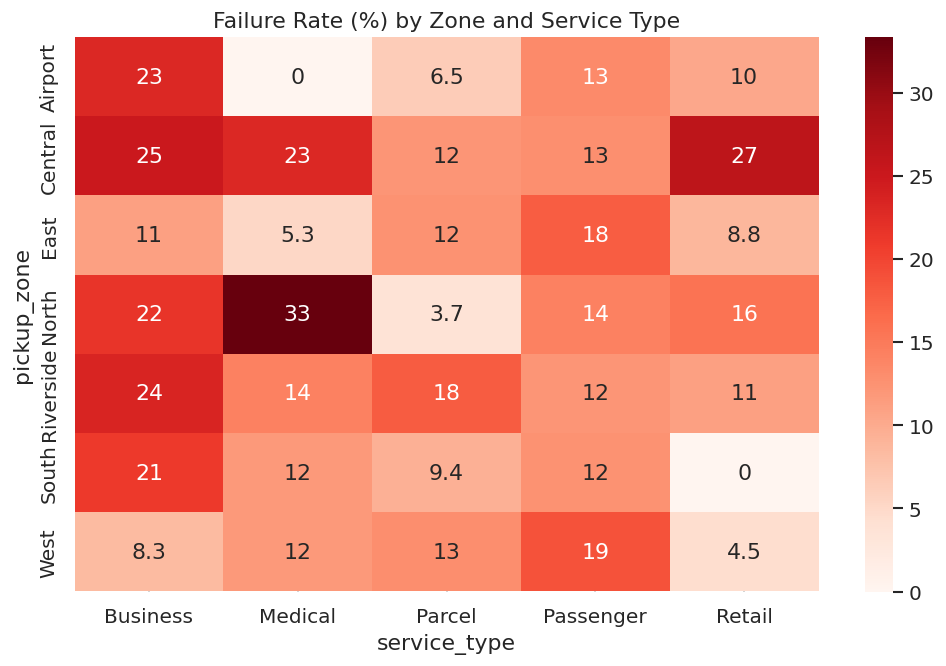

In [28]:
# Merge delivery data with order-level details
df = deliveries.merge(
    orders[['order_id', 'pickup_zone', 'service_type']],
    on='order_id',
    how='left'
)

# Compute failure rate by zone and service type
pivot = df.groupby(['pickup_zone', 'service_type'])['is_failed'].mean().unstack(fill_value=0)

# Plot heatmap of failure rates
plt.figure(figsize=(10,6))
sns.heatmap(pivot * 100, annot=True, cmap='Reds')
plt.title("Failure Rate (%) by Zone and Service Type")
plt.show()

**Interpretation**

* **Medical** services in the **North** zone have the highest failure rate (**33%**)
* **Business** deliveries show a systemic weakness, with consistently high failure rates in **Central (25%)**, **South Riverside (24%)**, and **North (22%)**.
* **Central** suffers from extreme volatility, particularly in **Retail (27%)** and **Business (25%)**, likely due to high-traffic congestion.
* **Parcel** and **Retail** services generally perform better, with **South** achieving a **0%** failure rate in Retail.
* Overall, the heatmap reveals that **Specialized Services (Medical/Business)** are failing at higher rates than **Standard Services (Parcel/Passenger)**, especially in high-volume zones.

## **Driver Risk Distribution**

Objective:

To analyse the distribution of driver risk scores in order to understand overall driver risk patterns across the fleet.

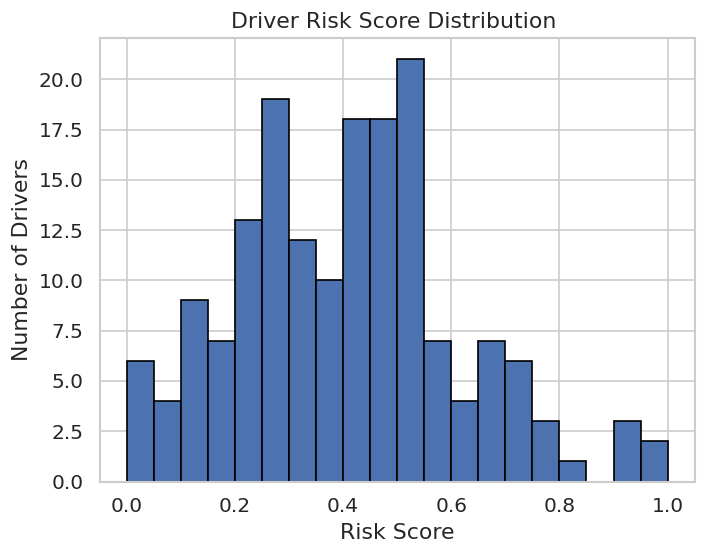

In [29]:
# Visualize distribution of driver risk scores
plt.hist(drivers['risk_score'].clip(0, 1), bins=20, edgecolor='black')

plt.title("Driver Risk Score Distribution ")
plt.xlabel("Risk Score")
plt.ylabel("Number of Drivers")

plt.show()

**Interpretation**/ Insight

- Most drivers have low risk scores, with only a few having higher scores.  
- The **peak frequency** occurs around **0.2**, where the number of drivers is highest (about 25).  
- Very few drivers have scores above **0.4**, showing that **high‑risk drivers are rare**.  
- Overall, the data suggests a predominantly low‑risk driver base, with only a handful of individuals showing elevated risk levels.


## **Complaint Analysis**

Objective:

To analyse the distribution of complaint statuses in order to understand how complaints are being resolved or managed within the system.

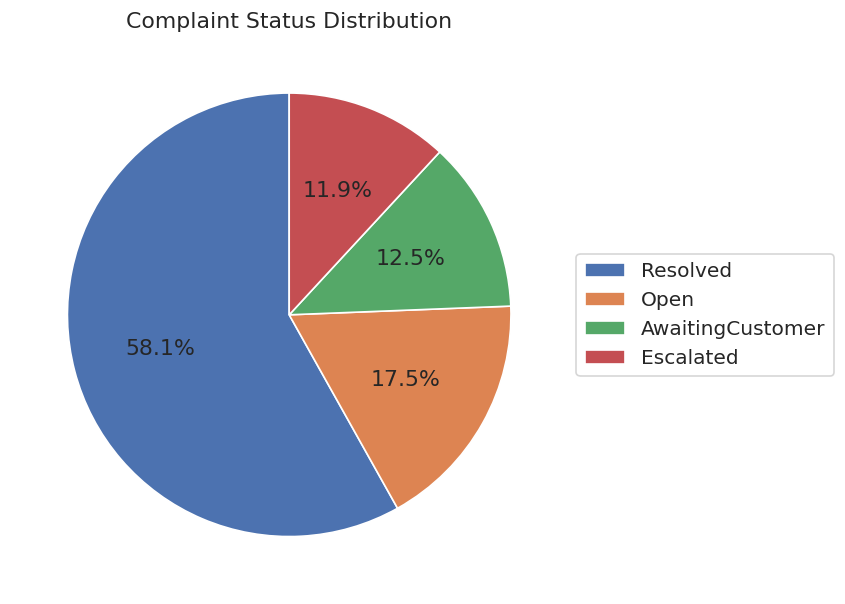

In [30]:
# Visualise complaint status distribution using a pie chart
plt.figure(figsize=(6,6))

status_counts = complaints['status'].value_counts()

plt.pie(
    status_counts,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Complaint Status Distribution")
plt.legend(
    status_counts.index,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.show()

**Interpretation**  


- The pie chart shows how customer complaints are distributed across different resolution stages.

- **Resolved (58.1%)** - The majority of complaints have been successfully addressed, indicating strong issue‑handling efficiency.  
- **Open (17.5%)** - A moderate portion of complaints are still being worked on, suggesting ongoing resolution efforts.  
- **Awaiting Customer (12.5%)** - Some cases are pending customer input, which may delay closure.  
- **Escalated (11.9%)** - A smaller share has required higher‑level attention, pointing to complex or unresolved issues.  
- This indicates that although resolution efficiency is strong, there are still gaps in communication flow, escalation handling, and timely follow-ups that may be impacting overall service experience.



## **Fleet Health**

Objective

To analyse fleet health by examining the relationship between vehicle usage (odometer readings) and battery health, while incorporating driver risk scores to identify potential high-risk operational patterns.

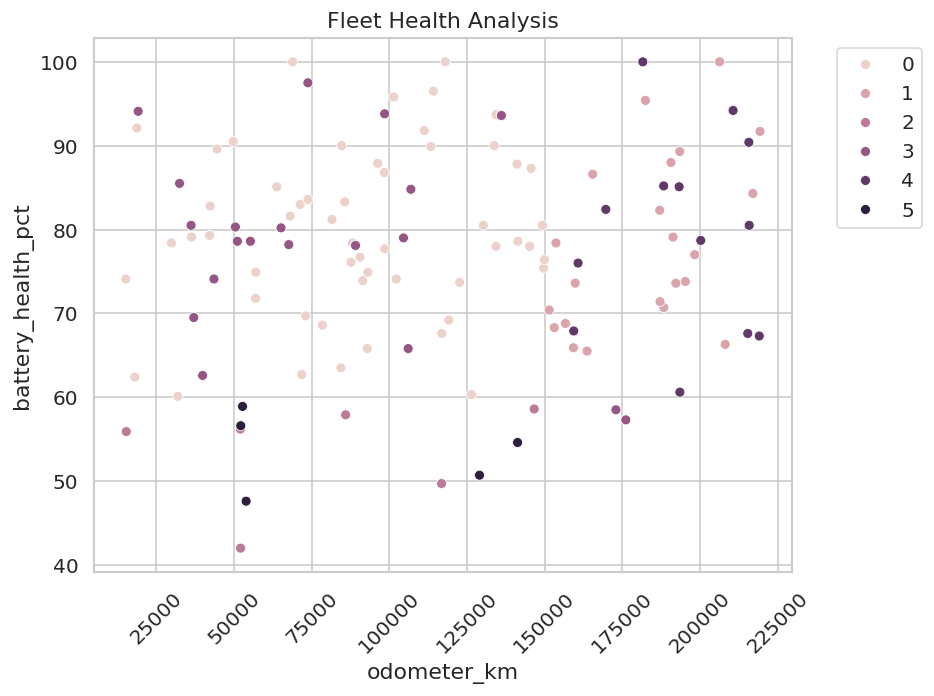

In [31]:
# Fleet health analysis: odometer vs battery health, coloured by risk score
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=vehicles,
    x='odometer_km',
    y='battery_health_pct',
    hue='risk_score'
)

plt.title("Fleet Health Analysis")

# Move legend outside plot (prevents overlap)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve x-axis readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Interpretation**

* The plot shows **vehicle usage (odometer km)** vs **battery health (%)**, with **risk score as the color gradient**.
* Most vehicles maintain **good battery health (70–90%)**, indicating overall stable fleet condition.
* There is **no strong relationship** between mileage and battery health, as high-mileage vehicles can still have good batteries.
* **Higher-risk vehicles are spread across the plot**, suggesting risk is not directly tied to mileage or battery condition alone.
* A few vehicles with **low battery health (<60%)** may need preventive maintenance.

* Overall, the fleet is generally healthy, but a small set of higher-risk, low-battery vehicles should be monitored closely.


**Conclusion**

The Python analysis identified key operational issues affecting NorthStar’s delivery performance, customer satisfaction, and operational efficiency. The results showed that delayed and failed deliveries are associated with higher route overrides, longer travel distances, increased costs, and operational inefficiencies.

The analysis also highlighted variations in hub performance, driver behaviour, vehicle condition, and complaint patterns across the organisation. Overall, Python-based data processing, analysis, and visualisation provided valuable insights that can support improved operational decision-making, delivery reliability, and service performance.